# JEPA Super-Resolution (low-res image -> high-res image)

Genuine upscaling: the network takes a low-resolution image, and predicts the
high-resolution version. Logic lives in `sr.py`; tune knobs in `config.py`
(`SR_*`). Run with **Run All** on a GPU runtime.


## Train


In [2]:
import importlib
import sr, config
importlib.reload(config)
importlib.reload(sr)

print("Device:", sr.DEVICE, "| scale x{} | channels {}".format(sr.SR_SCALE, sr.SR_CHANNELS))
model = sr.train()


Device: cuda | scale x4 | channels 3
Beginning SR training from fresh weights.
Training SR epochs 1 to 10 on cuda.
Epoch 1 | Step 10 | L1: 0.0812 | PSNR 19.02 dB (bicubic 24.29 dB)
Epoch 1 | Step 20 | L1: 0.0477 | PSNR 22.83 dB (bicubic 24.33 dB)
Epoch 1 | Step 30 | L1: 0.0441 | PSNR 23.61 dB (bicubic 24.35 dB)
Epoch 1 | Step 40 | L1: 0.0393 | PSNR 24.41 dB (bicubic 24.65 dB)
Epoch 1 | Step 50 | L1: 0.0387 | PSNR 24.45 dB (bicubic 24.62 dB)
Epoch 1 | Step 60 | L1: 0.0398 | PSNR 24.09 dB (bicubic 24.20 dB)
Epoch 1 | Step 70 | L1: 0.0376 | PSNR 24.57 dB (bicubic 24.67 dB)
End epoch 1 | Avg L1: 0.0575 | Avg PSNR: 22.71 dB | LR: 1.95e-04
Saved checkpoint: jepa_sr.pth
Epoch 2 | Step 10 | L1: 0.0389 | PSNR 24.24 dB (bicubic 24.29 dB)
Epoch 2 | Step 20 | L1: 0.0388 | PSNR 24.28 dB (bicubic 24.33 dB)
Epoch 2 | Step 30 | L1: 0.0387 | PSNR 24.28 dB (bicubic 24.35 dB)
Epoch 2 | Step 40 | L1: 0.0378 | PSNR 24.56 dB (bicubic 24.65 dB)
Epoch 2 | Step 50 | L1: 0.0380 | PSNR 24.52 dB (bicubic 24.62 dB

## Inference + PSNR (degrade a test image, then super-resolve it)


load time: 116093519 ns | inference: 91457499 ns
PSNR  super-res: 24.32 dB  |  bicubic baseline: 29.35 dB
Saved super-resolved image: sr_reconstruction.png


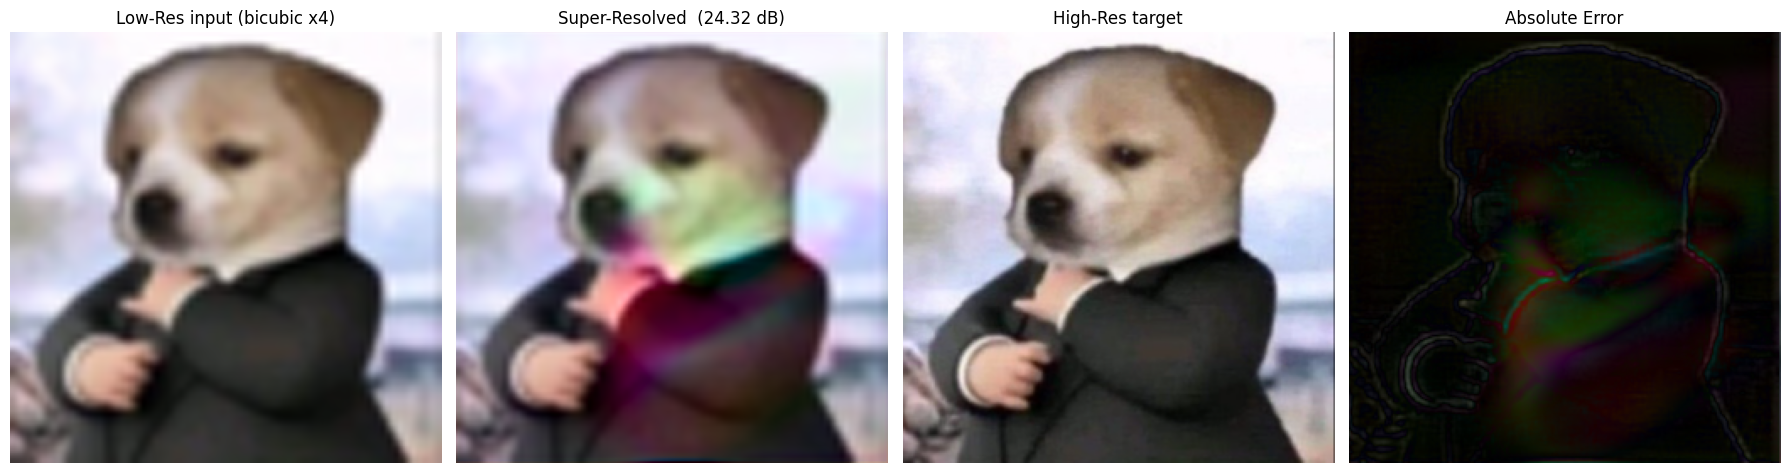

Super-res PSNR: 24.32 dB  vs  bicubic baseline: 29.35 dB


In [3]:
import matplotlib.pyplot as plt

result = sr.run_inference(model)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
panels = [
    ("Low-Res input (bicubic x{})".format(sr.SR_SCALE), result["low_res"]),
    ("Super-Resolved  ({:.2f} dB)".format(result["sr_psnr"]), result["super_res"]),
    ("High-Res target", result["high_res"]),
    ("Absolute Error", result["error"]),
]
for ax, (title, img) in zip(axes, panels):
    if img.ndim == 2:
        ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    else:
        ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

print("Super-res PSNR: {:.2f} dB  vs  bicubic baseline: {:.2f} dB".format(
    result["sr_psnr"], result["baseline_psnr"]))


## Super-resolve a real low-res image

Use this on an actual low-quality file (no high-res reference needed). It just
upsamples the input to the network size and refines it.


In [4]:
# sr_image = sr.super_resolve(config.IMAGE_PATH, model=model, save_path="sr_real.png")
# import matplotlib.pyplot as plt
# plt.figure(figsize=(6,6)); plt.imshow(sr_image); plt.axis('off'); plt.show()
